In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [ ]:
nom_region = "Ile_de_France"
region_code='77'


C:\Users\lilym\AppData\Local\Temp\ipykernel_31232\3728333838.py:3: DtypeWarning: Columns (158) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(f'Dpe_dep_{region_code}.csv')


In [ ]:
df=pd.read_csv(f'DPE_{region_code}.csv')

In [21]:
# On initialise la nouvelle colonne à 0 pour tout le monde
df['conso_totale_elec_finale'] = 0

# On vérifie l'énergie n°1
df['conso_totale_elec_finale'] = np.where(
    df['type_energie_n1'] == 'Électricité', 
    df['conso_5_usages_ef_energie_n1'], 
    df['conso_totale_elec_finale']
)

# On ajoute l'énergie n°2 (si jamais l'électricité est en 2ème position)
df['conso_totale_elec_finale'] = np.where(
    df['type_energie_n2'] == 'Électricité', 
    df['conso_totale_elec_finale'] + df['conso_5_usages_ef_energie_n2'], 
    df['conso_totale_elec_finale']
)

# Exemple de simplification dans Pandas
df['ventilation_simplifiee'] = 'Autre / Inconnu'

# 1. On regroupe tout ce qui est Naturel / Ancien
df.loc[df['type_ventilation'].str.contains('naturelle|Aucune', case=False, na=False), 'ventilation_simplifiee'] = 'Naturelle'

# 2. On regroupe toutes les VMC Simple Flux (qu'elles soient auto ou hygro)
df.loc[df['type_ventilation'].str.contains('Simple flux', case=False, na=False), 'ventilation_simplifiee'] = 'VMC Simple Flux'

# 3. On isole la Double Flux
df.loc[df['type_ventilation'].str.contains('Double flux', case=False, na=False), 'ventilation_simplifiee'] = 'VMC Double Flux'

df['presence_climatisation'] = np.where(df['conso_refroidissement_ef'] > 0, 1, 0)

C:\Users\lilym\AppData\Local\Temp\ipykernel_31232\659428834.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=repartition.index, y=repartition.values, palette="viridis")


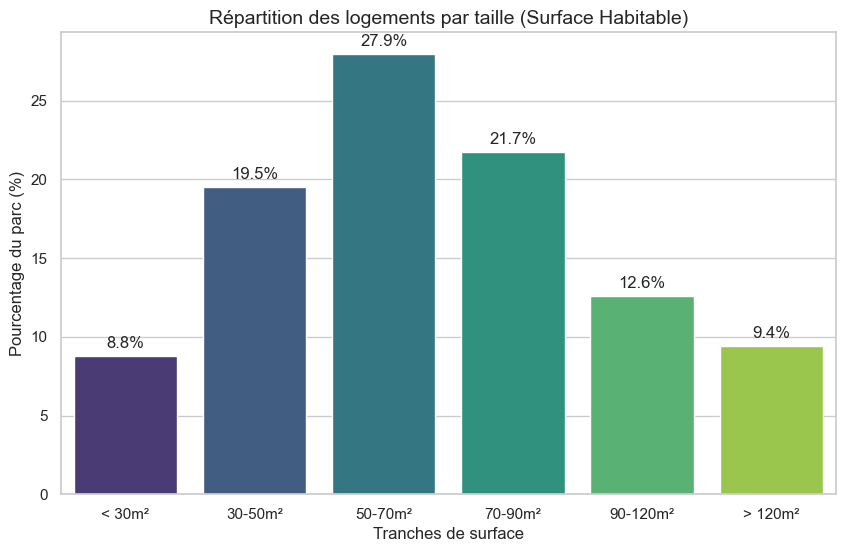

In [23]:
# 1. Définition des tranches de surface (bins)
bins = [0, 30, 50, 70, 90, 120, float('inf')]
labels = ['< 30m²', '30-50m²', '50-70m²', '70-90m²', '90-120m²', '> 120m²']

# 2. Création de la nouvelle colonne de segmentation
# On vérifie si la colonne existe avant de traiter
surface_col = 'surface_habitable_logement'

if surface_col in df.columns:
    # On retire les valeurs aberrantes ou nulles pour le graphique
    df_clean = df[df[surface_col] > 0].copy()
    
    df_clean['tranche_surface'] = pd.cut(df_clean[surface_col], bins=bins, labels=labels)

    # 3. Calcul de la répartition
    repartition = df_clean['tranche_surface'].value_counts(normalize=True).sort_index() * 100

    # 4. Visualisation
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    ax = sns.barplot(x=repartition.index, y=repartition.values, palette="viridis")

    plt.title('Répartition des logements par taille (Surface Habitable)', fontsize=14)
    plt.xlabel('Tranches de surface', fontsize=12)
    plt.ylabel('Pourcentage du parc (%)', fontsize=12)

    # Ajout des étiquettes de pourcentage sur les barres
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    plt.show()
else:
    print(f"La colonne {surface_col} est introuvable. Vérifie le nom exact dans ton dataset.")

In [51]:
features_cat = [
    'type_batiment', 
    'zone_climatique', 
    'classe_altitude',
    'chauffage_simplifie',        
    'logement_traversant_clean',  
    'isolation_toiture_clean',
    'qualite_isolation_enveloppe',
    'periode_construction',
    'qualite_isolation_murs',
    'qualite_isolation_menuiseries',
    'qualite_isolation_plancher_bas',
    'type_emetteur_installation_chauffage_n1',
    'type_installation_ecs',
    'type_generateur_n1_ecs_n1',
    'presence_brasseur_air',
    'protection_solaire_exterieure',
    'presence_climatisation',
    'ventilation_simplifiee',
    'etiquette_dpe'
]

features_num = [
    'surface_habitable_logement',
    'annee_construction', 
    'hauteur_sous_plafond',
    'ubat_w_par_m2_k',
    'besoin_chauffage',
    'apport_solaire_saison_chauffe'
]

target = 'conso_totale_elec_finale'

tranches = df_clean['tranche_surface'].unique()

In [52]:
# On combine les deux listes pour créer notre X complet
colonnes_a_garder = features_cat + features_num

# 2. Définir X et y (en s'assurant que les colonnes existent bien dans df)
# On filtre pour ne garder que les colonnes qui sont bien présentes dans le dataset
colonnes_presentes = [col for col in colonnes_a_garder if col in df.columns]
X = df[colonnes_presentes].copy()
y = df['conso_totale_elec_finale'].copy()

# 2.A - Le filtre de base (enlever les valeurs manquantes ou infinies)
masque_base = ~y.isna() & ~np.isinf(y)

# 2.B - Le filtre de bon sens physique
# Moins de 500 kWh : Impossible pour un logement occupé (même passif, il y a le frigo et l'eau chaude)
# Plus de 60 000 kWh : C'est soit un château, soit une grosse faute de frappe sur le DPE.
masque_bon_sens = (y >= 500) & (y <= 60000)

# On combine les deux filtres
masque_final = masque_base & masque_bon_sens

# On applique le couperet sur X et sur y
X = X[masque_final]
y = y[masque_final]

print(f"Logements conservés après filtrage : {len(y)}")

for col in features_cat:
    if col in X.columns:
        X[col] = X[col].astype(str).astype('category')

# 5. Séparation Train / Test (On cache 20% des données pour l'examen final)
# random_state=42 permet d'avoir toujours la même séparation si vous relancez le code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entraînement sur {len(X_train)} logements.")
print(f"Test sur {len(X_test)} logements cachés.")

# 6. Instancier et entraîner le modèle UNIQUEMENT sur le Train
model = xgb.XGBRegressor(
    n_estimators=150, 
    max_depth=6,
    enable_categorical=True, 
    random_state=42,
    n_jobs=-1
)

print("Entraînement en cours...")
model.fit(X_train, y_train)

# 7. Faire passer l'examen au modèle (Prédictions sur le Test)
y_pred = model.predict(X_test)

# 8. Calculer les scores !
mon_r2 = r2_score(y_test, y_pred)
mon_mae = mean_absolute_error(y_test, y_pred)

print("-" * 30)
print("RÉSULTATS DU MODÈLE :")
print(f"Score R² : {mon_r2:.3f}")
print(f"Marge d'erreur moyenne (MAE) : {mon_mae:.0f} kWh")
print("-" * 30)

Logements conservés après filtrage : 182398
Entraînement sur 145918 logements.
Test sur 36480 logements cachés.
Entraînement en cours...
------------------------------
RÉSULTATS DU MODÈLE :
Score R² : 0.829
Marge d'erreur moyenne (MAE) : 924 kWh
------------------------------


In [53]:
def entrainer_tranche(df, nom_tranche):
    # 1. Filtrer pour la tranche
    data = df[df['tranche_surface'] == nom_tranche].copy()
    
    data = data.dropna(subset=[target]) 
    data = data[np.isfinite(data[target])] 
    data = data[data[target] > 0]

    if len(data) < 50: # Sécurité : pas de modèle si trop peu de données
        return None
    
    X = data[features_cat + features_num]
    y = data[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 2. Prétraitement (Le OneHotEncoder va créer toutes les colonnes manquantes)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), features_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
        ]
    )
    
    # 3. Le Pipeline XGBoost
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6))
    ])
    
    # 4. Entraînement
    pipeline.fit(X_train, y_train)
    
    # 5. Scores (Modifié ici)
    y_pred = pipeline.predict(X_test) # On stocke les prédictions pour ne les calculer qu'une fois
    
    score_r2 = r2_score(y_test, y_pred)
    score_rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calcul du RMSE
    
    # On ajoute le RMSE au dictionnaire de retour
    return {'model': pipeline, 'r2': score_r2, 'rmse': score_rmse, 'tranche': nom_tranche}

In [ ]:
import os
import pickle
import pandas as pd

dictionnaire_modeles = {}

# --- CORRECTION 1 : Créer le dossier de la région s'il n'existe pas ---
os.makedirs(nom_region, exist_ok=True)

for t in tranches:
    tranche_clean = t.replace(' ', '').replace('²', '2').replace('<', 'inf').replace('>', 'sup')
    nom_fichier = f"{nom_region}/pipeline_{nom_region}_{tranche_clean}_elec.pkl"
    
    if os.path.exists(nom_fichier):
        print(f"✅ Le modèle pour {nom_region} ({tranche_clean}) existe déjà ({nom_fichier}). Entraînement annulé.")
        
        # Optionnel : Si le modèle existe déjà, on le charge dans notre dictionnaire pour pouvoir l'utiliser
        with open(nom_fichier, 'rb') as f:
            dictionnaire_modeles[t] = pickle.load(f)

    else:
        print(f"🧠 Entraînement de la tranche : {t}...")
        resultat = entrainer_tranche(df_clean, t)
        
        if resultat:
            pipeline = resultat['model']
            
            # --- CORRECTION 2 : On stocke le modèle dans le dictionnaire ---
            dictionnaire_modeles[t] = pipeline
            
            # --- ÉTAPE 2 : Sauvegarde immédiate du fichier .pkl ---
            with open(nom_fichier, 'wb') as f:
                pickle.dump(pipeline, f)
                
            print(f"💾 Nouveau modèle sauvegardé sous : {nom_fichier} (R2: {resultat['r2']:.4f})")

            # 1. Récupération de vos métriques
            score_r2 = resultat['r2']
            score_rmse = resultat['rmse']

            # 2. Création d'un petit DataFrame avec les résultats de cette région
            nouvelle_ligne = pd.DataFrame({
                'Region': [nom_region],       # La variable définie par Papermill
                'Tranche': [t],
                'Type': ['DPE'],              # Le nom de votre algorithme
                'R2_Score': [score_r2],
                'RMSE': [score_rmse]
            })

            # 3. Nom du fichier CSV central qui va regrouper tous les résultats
            fichier_resultats = 'performances_modeles.csv'

            # 4. Sauvegarde dans le CSV (avec la logique d'ajout)
            if not os.path.exists(fichier_resultats):
                nouvelle_ligne.to_csv(fichier_resultats, index=False)
            else:
                nouvelle_ligne.to_csv(fichier_resultats, mode='a', header=False, index=False)

            print(f"📊 Résultats sauvegardés pour {nom_region} ({t}) ! (R²: {score_r2:.3f}, RMSE: {score_rmse:.0f})\n")
            
        else:
            # CORRECTION 3 : Savoir quand une tranche échoue
            print(f"⚠️ Pas assez de données (ou erreur) pour la tranche {t}. Aucun modèle sauvegardé.\n")


# Exemple pour tester un modèle à la fin de la boucle (ex: la tranche '40-60')
# dictionnaire_modeles['40-60'].predict(un_nouveau_logement_brut)

💾 Nouveau modèle sauvegardé sous : Ile_de_France/pipeline_Ile_de_France_90-120m2_dpe.pkl
Entraînement de la tranche : 90-120m²...
📊 Résultats sauvegardés pour Ile_de_France ! (R²: 0.793, RMSE: 2746)
💾 Nouveau modèle sauvegardé sous : Ile_de_France/pipeline_Ile_de_France_70-90m2_dpe.pkl
Entraînement de la tranche : 70-90m²...
📊 Résultats sauvegardés pour Ile_de_France ! (R²: 0.842, RMSE: 1767)
💾 Nouveau modèle sauvegardé sous : Ile_de_France/pipeline_Ile_de_France_50-70m2_dpe.pkl
Entraînement de la tranche : 50-70m²...
📊 Résultats sauvegardés pour Ile_de_France ! (R²: 0.883, RMSE: 1209)
💾 Nouveau modèle sauvegardé sous : Ile_de_France/pipeline_Ile_de_France_inf30m2_dpe.pkl
Entraînement de la tranche : < 30m²...
📊 Résultats sauvegardés pour Ile_de_France ! (R²: 0.929, RMSE: 617)
💾 Nouveau modèle sauvegardé sous : Ile_de_France/pipeline_Ile_de_France_sup120m2_dpe.pkl
Entraînement de la tranche : > 120m²...
📊 Résultats sauvegardés pour Ile_de_France ! (R²: 0.685, RMSE: 5545)
💾 Nouveau modè

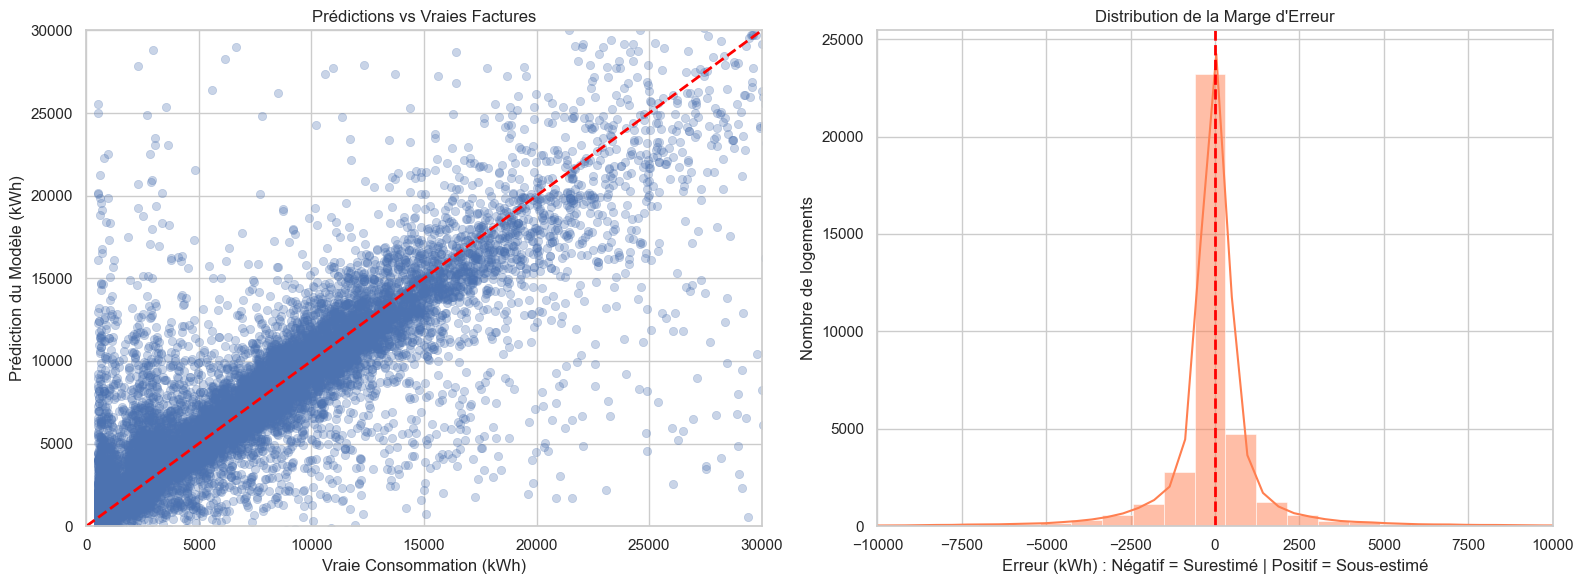

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Création d'un tableau récapitulatif des erreurs
resultats = pd.DataFrame({
    'Vraie_Consommation': y_test,
    'Prediction_Modele': y_pred
})
# L'erreur (Le Résidu) : Si positif = le modèle a sous-estimé la facture. Si négatif = il a surestimé.
resultats['Erreur_kWh'] = resultats['Vraie_Consommation'] - resultats['Prediction_Modele']

# 2. Configuration de l'affichage (2 graphiques côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPHIQUE 1 : Nuage de points (Vrai vs Prédiction) ---
sns.scatterplot(
    data=resultats, 
    x='Vraie_Consommation', 
    y='Prediction_Modele', 
    alpha=0.3, # Transparence pour voir la densité
    edgecolor=None,
    ax=axes[0]
)
# La ligne parfaite (y = x) : Si le modèle était parfait, tous les points seraient sur cette ligne rouge
val_max = min(resultats['Vraie_Consommation'].max(), 30000) # On limite à 30 000 kWh pour y voir clair
axes[0].plot([0, val_max], [0, val_max], color='red', linestyle='--', linewidth=2)
axes[0].set_xlim(0, 30000)
axes[0].set_ylim(0, 30000)
axes[0].set_title('Prédictions vs Vraies Factures')
axes[0].set_xlabel('Vraie Consommation (kWh)')
axes[0].set_ylabel('Prédiction du Modèle (kWh)')

# --- GRAPHIQUE 2 : Distribution des Erreurs (Histogramme) ---
sns.histplot(resultats['Erreur_kWh'], bins=100, kde=True, ax=axes[1], color='coral')
axes[1].set_xlim(-10000, 10000) # On zoome sur l'essentiel
axes[1].axvline(0, color='red', linestyle='--', linewidth=2) # La ligne d'erreur Zéro
axes[1].set_title('Distribution de la Marge d\'Erreur')
axes[1].set_xlabel('Erreur (kWh) : Négatif = Surestimé | Positif = Sous-estimé')
axes[1].set_ylabel('Nombre de logements')

plt.tight_layout()
plt.show()